# Load Necessary Tools
Vizualization References
[Pandas](http://pandas.pydata.org/pandas-docs/stable/visualization.html),
[Seaborn](https://seaborn.pydata.org/)

In [79]:
# Ensure Cuda is in Path
# !echo $PATH

# Import Helper Libraries
import data_utils
# Reload Tweaked/Edited Helper Libraries 
import importlib
importlib.reload(data_utils)

#from helper_libs.data_utils import *
#from helper_libs.model_utilities import *
#from helper_libs.churn_io import *

# Initialize Run Tracker
RUN=1
# Data Sci 
import pandas as pd
import numpy as np
from sklearn import metrics # roc_curve, roc_auc_score, auc, average_precision_score
from scipy.stats import boxcox
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.decomposition import PCA


# ML
import tensorflow as tf
from tensorflow.contrib import keras
Sequential = keras.models.Sequential
Dense = keras.layers.Dense
Dropout = keras.layers.Dropout
Activation = keras.layers.Activation
GaussianNoise = keras.layers.GaussianNoise
BatchNormalization = keras.layers.BatchNormalization


# OS
from subprocess import call

# Viz
%matplotlib inline
import matplotlib
matplotlib.style.use('ggplot')
from matplotlib import pyplot as plt
from pandas.tools.plotting import scatter_matrix
import time
import datetime

# Import Data, Define Additional Vars

In [26]:
x_train, y_train, x_valid, y_valid, x_test, y_test = data_utils.get_data(
    tr='rec', 
    bins=0, 
    threshold=2,
    fnorm='fn11',
    from_redshift=False)

Retrieving saved query data.
Reciprocating!
vod_v1 59
vod_v2 59
vod_acc 100
nxt_v1 159
nxt_v2 143
nxt_acc 217
num_vol_losses 15
pmt_pct_days_paid 120902
num_pmts 42
pct_ppv1 29271
num_invol_fail 65
vod_lst_30days 31
vod_lst_30to60days 31
vod_lst_60to90days 31
nxt_view_ep_lst_90days 127
nxt_view_ep_lst_30days 91
nxt_lst_30to60days 84
nxt_lst_60to90days 70
num_strms_vshp_all 4076
vod_num_strms 3884
num_nc_em_rcvd_1st_60days 24
overall_num_device_types 18
num_strms_vshp_net_orig 1168
num_strms_vshp_ring 1838
avg_rebuf_ratio_lst_30days 6064
avg_rebuf_ratio_lst_60days 5950
avg_rebuf_ratio_lst_90days 5999
Tranform Complete!
Beginning rescale...
Scaling Complete!


### What are we working with?

X Training:    (n_instances, n_features) =  (711604, 76)
X Validation:  (n_instances, n_features) =  (88950, 76)
X Test:        (n_instances, n_features) =  (88951, 76)
Data Type:  float32
Min: -1.0 Mean: 0.299916 Max: 1.0


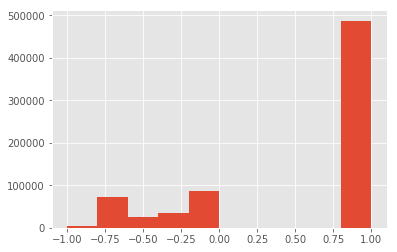

In [27]:
#x_train, y_train, x_valid, y_valid, x_test, y_test = churn_transform(raw_data)n_classes = raw_data['n_classes']


print('X Training:    (n_instances, n_features) = ', x_train.shape)
print('X Validation:  (n_instances, n_features) = ', x_valid.shape)
print('X Test:        (n_instances, n_features) = ', x_test.shape)
print('Data Type: ', x_train['nxt_view_ep_lst_90days'].dtype)
print('Min:', x_train.loc[:,'nxt_view_ep_lst_90days'].min(), 'Mean:', x_train.loc[:,'nxt_view_ep_lst_90days'].mean(), 'Max:', x_train.loc[:,'nxt_view_ep_lst_90days'].max())
x_train.loc[:,'nxt_view_ep_lst_30days'].hist()


In [80]:
#==============================================
# Choose x_cols
#==============================================
#features = varnames('exl5','vod_pos','nxt_pos','months')
features = data_utils.varnames('exl4','vod_pos','nxt_pos','months')
#features = exl5 + vod_pos + nxt_pos + b4
#features = varnames('exl5','vod30','vod3060','nxt30','nxt3060','months','b4')

xx_train = x_train.loc[:, features].values
xx_valid = x_valid.loc[:, features].values
xx_test  = x_test.loc[:,  features].values
#if str(type(y_train)) != "<class 'numpy.ndarray'>":
yy_train = y_train.values
yy_valid = y_valid.values
yy_test  = y_test.values


# Data Shape
n_train = xx_train.shape[0]
n_valid = xx_valid.shape[0]
n_test  = xx_test.shape[0]
n_data_tot = n_train + n_valid + n_test
n_data_train = xx_train.shape[0]
n_features = xx_train.shape[1]
n_classes  = yy_train.shape[1]
    

print('Chosen Inputs: ', x_train.loc[:, features].columns, '\n')
print('Event: ', 'CHURN')  # y_cols deleted at one pont...
print('Num Classes: ', n_classes)
print('X Shape: ', xx_train.shape)


Chosen Inputs:  Index(['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may',
       'no_view_90days_flag', 'nov', 'num_vol_losses', 'nxt_lst_30to60days',
       'nxt_lst_60to90days', 'nxt_view_ep_lst_30days', 'oct', 'pct_ppv1',
       'pmt_pct_days_paid', 'sep', 'vod_lst_30days', 'vod_lst_30to60days',
       'vod_lst_60to90days'],
      dtype='object') 

Event:  CHURN
Num Classes:  1
X Shape:  (711604, 22)


In [7]:
# http://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html#sphx-glr-auto-examples-decomposition-plot-pca-vs-lda-py
#pca = PCA(n_components=17)
#lda = LDA(n_components=11, solver='eigen')
#z1 = pca.fit(xx_train).transform(xx_train)
#z2 = lda.fit(z1, np.ravel(y_train)).transform(z1)
#xx_train=z2

In [ ]:
# Or can set up autoencoder
# Autoencoder @ 12:31:  https://youtu.be/Tp3SaRbql4k

In [81]:
# Keras Model
## Input Layer..
model = Sequential()
## HL1
model.add(Dense(11, input_dim=xx_train.shape[1]))
model.add(GaussianNoise(0.1))
model.add(BatchNormalization())
model.add(Activation('relu'))
## HL2
model.add(Dense(11))
model.add(GaussianNoise(0.1))
model.add(Activation('relu'))
## HL3
model.add(Dense(11))
model.add(GaussianNoise(0.1))
model.add(Activation('relu'))
## HL4
model.add(Dense(11))
model.add(GaussianNoise(0.1))
model.add(Activation('relu'))
## HL5
model.add(Dense(11))
model.add(GaussianNoise(0.1))
model.add(Activation('relu'))
## Output Layer
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(xx_train, yy_train, epochs=200, batch_size=50000)

Epoch 1/200
711604/711604 [==============================] - 1s - loss: 0.5807 - acc: 0.8315     

## Scores

In [82]:
print("Keras!")
y_pred_train = model.predict(xx_train)
y_pred_valid = model.predict(xx_valid)
y_pred_test = model.predict(xx_test)
        


Keras!


In [84]:
thresh = 0.5   
    
yy_class_train = np.array(y_pred_train > thresh, dtype=np.float32)     
#y_class_valid = np.array(y_pred_valid > thresh, dtype=np.float32) 
#y_class_test = np.array(y_pred_test > thresh, dtype=np.float32) 
    
print('|           | Training | Validation |')
print(
    '| RO-AUC    | ',
    round(100*metrics.roc_auc_score(yy_train, y_pred_train),1), ' | ',
    #round(100*metrics.roc_auc_score(yy_valid, y_pred_valid),1), ' | '
)
    
# Precision: 
#  -- precision is the ability of the classifier not to label a negative sample as positive
#  -- precision = tp / (tp+fp)
print(
    '| Precision | ',
    round(100*metrics.precision_score(yy_train, y_class_train),1), ' | ',
    #round(100*metrics.precision_score(yy_valid, y_class_valid),1), ' | '
)

# Recall: 
#  -- recall is the ability of the classifier to find all the positive samples
print(
    '| Recall    | ', 
    round(100*metrics.recall_score(yy_train, y_class_train),1), ' | ',
    #round(100*metrics.recall_score(yy_valid, y_class_valid),1), ' | '
)

# Average Precision: Area under the Precision-Recall curve
#  -- precision = tp / (tp+fp)
#  -- recall = tp / (tp+fn)
print(
    '| PR-AUC    | ',
    round(100*metrics.average_precision_score(yy_train, y_pred_train),1), ' | ',
    #round(100*metrics.average_precision_score(yy_valid, y_pred_valid),1), ' | '
)

# F1 Score
#  -- must binarize y_pred (e.g., what threshold is roc_auc_score using?)
#  -- f1 = harmonic_mean(precision, recall) = 2pr/(p+r)
#  -- y_class = ...
print(
    '| F1 Score  | ',
    round(100*metrics.f1_score(y_train, yy_class_train),1), ' | ',
    #round(100*metrics.f1_score(y_valid, yy_class_valid),1), ' | '
)

#print('| Accuracy  | ',round(100*metrics.accuracy_score(y_actual, y_class, normalize=True),1), ' | ')
#print('| R2 Score  | ', round(100*metrics.r2_score(y_actual, y_pred),1), ' | ')
#print('| MnAbsErr  | ', round(100*metrics.mean_absolute_error(y_actual, y_pred),1), ' | ')
#print('| MnSqErr   | ', round(100*metrics.mean_squared_error(y_actual, y_pred),1), ' | ')
#print('| MedAbsErr | ', round(100*metrics.median_absolute_error(y_actual, y_pred),1), ' | ')

|           | Training | Validation |
| RO-AUC    |  75.4  | 
| Precision |  60.2  | 
| Recall    |  8.7  | 
| PR-AUC    |  26.6  | 
| F1 Score  |  15.2  | 


In [85]:
today = datetime.date.today().strftime ("%Y-%m-%d")
model.save(today+"__Keras")

In [44]:
#model.to_yaml()

## Gain plots

* [lift charts](http://www2.cs.uregina.ca/~dbd/cs831/notes/lift_chart/lift_chart.html)
* [MSFT explanation](https://docs.microsoft.com/en-us/sql/analysis-services/data-mining/lift-chart-analysis-services-data-mining)


1.  Order (y_pred, churn=y_valid (or y_test)) by y_pred
2.  Break into deciles 
3.  For each decile:
    - record exact population size
    - record number of churners
    - compute churn rate (churners/popSize)
    - compute % of all churners (theseChurners/allChurners)
    - compute cumaltive % of churners
    - show what cumalative % of churners would be if groups were randomly selected from general population

Can also record number of predicted churners...

In [58]:
yy_train.shape

(711604, 1)

In [71]:
# 0. Choose y_valid or y_test

# UPDATE: 2017-05-04:
#   -- new code means that we have to restore ckpt model data before this...
#   -- doing other stuff now / update this section later

#y_set = 'Valid'  # 'valid' or 'test'
#if y_set=='Valid': 
#    y_actual = y_valid
#    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_valid})
#else:
#    y_actual = y_test
#    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_test})#
"""

y_actual = np.append(
    np.append(yy_train,      yy_valid,      axis=0),
    yy_test,
    axis=0
)
y_pred   = np.append(
    np.append( y_pred_train, y_pred_valid, axis=0),
    y_pred_test,
    axis=0
)
"""

y_actual = np.append(yy_train,      yy_valid,     axis=0)
y_pred   = np.append( y_pred_train, y_pred_valid, axis=0)


# 1. Order (y_pred, churn=y_valid (or y_test)) by y_pred
sortIndex      =  np.argsort(y_pred[:,0])
sortIndex      =  sortIndex[::-1]
y_pred_sorted  =  y_pred[sortIndex,0]
y_sorted       =  y_actual[sortIndex,0]

# 2. Break y_pred and churn arrays into deciles 
#    -- since arrays are same length, np.array_split() splits them
#       into same-sized groups (all equal if possible)
y_pred_deciles = np.array_split(y_pred_sorted, 10)
y_deciles      = np.array_split(y_sorted, 10)


# 3. Record decile properties 
# - Population size for each decile
decile = np.linspace(1,10,10)
decile_size = np.array([len(decile) 
                        for decile in y_pred_deciles])
# - Number of actual churners in each decile
num_churners = np.array([sum(decile) 
                         for decile in y_deciles])
# - Churn Rate (churners/popSize)
churn_rate = np.array([round(100*n_churn/decile_size[i],1)
                       for i,n_churn in enumerate(num_churners)])
# - Number of All Churners
all_churners = np.repeat(np.sum(num_churners), 10)
# - Decile's Churner Stock:  num_churners / all_churners
proportion_of_churn = np.array([round(100*n_churn/all_churners[0],2) 
                          for n_churn in num_churners])
# - Cumulative sum of Churner Stock
cum_prop = np.cumsum(proportion_of_churn)
# - Cumulative sum of Churner Stock if Deciles were randomized groups
cum_control = np.linspace(10,100,10)

# Generate Pandas DataFrame
churnTable = pd.DataFrame({
    'decile': decile,
    'size': decile_size,
    'num_churn': num_churners,
    'churn_rate': churn_rate,
    'all_churn': all_churners,
    'proportion_of_churn': proportion_of_churn,
    'cum_prop': cum_prop,
    'cum_control': cum_control
})
churnTable=churnTable[['decile','size','num_churn','churn_rate','all_churn','proportion_of_churn','cum_prop','cum_control']]

In [72]:
#plt.plot(y_pred[indices,0])
#fileName='name'
#churnTable.to_csv('Model-Data/'+fileName+'.csv')
churnTable

,decile,size,num_churn,churn_rate,all_churn,proportion_of_churn,cum_prop,cum_control
0,1.0,80056,20677,25.8,56499,36.60,36.60,10.0
1,2.0,80056,8932,11.2,56499,15.81,52.41,20.0
2,3.0,80056,6718,8.4,56499,11.89,64.30,30.0
3,4.0,80056,5278,6.6,56499,9.34,73.64,40.0
4,5.0,80055,4048,5.1,56499,7.16,80.80,50.0
5,6.0,80055,3255,4.1,56499,5.76,86.56,60.0
6,7.0,80055,2558,3.2,56499,4.53,91.09,70.0
7,8.0,80055,2179,2.7,56499,3.86,94.95,80.0
8,9.0,80055,1756,2.2,56499,3.11,98.06,90.0
9,10.0,80055,1098,1.4,56499,1.94,100.00,100.0


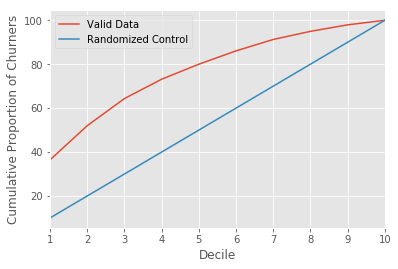

In [33]:
#plt.plot(churnTable['cum_stock'])
#plt.plot(churnTable['cum_stock_control'])
#churnTable['cum_prop'].plot()
#churnTable['cum_control'].plot()
fig = churnTable.plot(x='decile',y=['cum_prop','cum_control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
fig.legend(labels=[y_set+' Data', 'Randomized Control'])

In [ ]:
from matplotlib

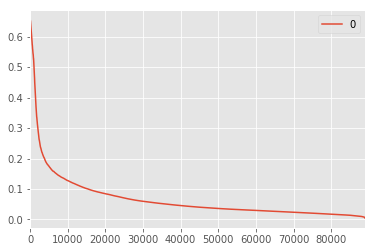

In [34]:
pd.DataFrame(y_pred_sorted).plot()

In [41]:
len(y_pred_sorted[(y_pred_sorted > 0.5) & (y_pred_sorted <= 0.6)])

675